# **Baseline : Regresja logistyczna**
## Analiza ryzyka płynności przedsiębiorstw
&emsp;Celem jest stworzenie punktu odniesienia (baseline) przewidującego prawdopodobieństwo opóźnienia płatności dla zamkniętych faktur.


### Narzędzia i biblioteki
&emsp; Zacznijmy od załadowania niezbędnych narzędzi.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, average_precision_score

plt.rcParams['figure.figsize'] = (8, 6)

### Wczytanie i filtracja danych oraz selekcja cech
&emsp;W tym kroku przygotujemy macierz danych do treningu modelu. Po wczytaniu zbioru odrzucimy wszystkie faktury otwarte (ocenzurowane), ponieważ klasyfikator binarny wymaga danych wyłącznie z zamkniętych transakcji o jednoznacznym statusie (zapłacone w terminie lub opóźnione). Następnie przeprowadzimy selekcję cech usuwając identyfikatory tekstowe, daty oraz kolumny zawierające dane o przyszłości z perspektywy momentu wystawienia faktury: np. kolumnę *days_late*. Model powinien uczyć się wyłącznie na danych, które są dostępne w momencie, w którym ma być wykorzystany do predykcji.

In [9]:
df_input = pd.read_csv('../data/dataset_survival.csv')
print(f"Wymiary macierzy wejściowej: {df_input.shape[0]} wierszy, {df_input.shape[1]} kolumn")

df_closed = df_input[df_input['isOpen'] == 0].copy()

leakage_cols = ['clear_date', 'days_late', 'event', 'time_days', 'isOpen']

id_cols = ['doc_id', 'invoice_id', 'cust_number', 'name_customer']
date_cols = ['document_create_date', 'due_in_date', 'baseline_create_date', 'buisness_year']

cols_to_drop = leakage_cols + id_cols + date_cols

df_closed.drop(columns=cols_to_drop, axis=1, inplace=True)

cols = df_closed.columns.tolist()
cols.remove('paid_late')
cols.append('paid_late')
df_closed = df_closed[cols]

print(f"Wymiary macierzy po obróbce: {df_closed.shape[0]} wierszy, {df_closed.shape[1]} kolumn")
print("\nWektor wejściowy (Features + Target):")
print(cols)

Wymiary macierzy wejściowej: 49999 wierszy, 19 kolumn
Wymiary macierzy po obróbce: 39999 wierszy, 6 kolumn

Wektor wejściowy (Features + Target):
['business_code', 'invoice_currency', 'total_open_amount', 'cust_payment_terms', 'segment', 'paid_late']


### Podział danych
&emsp;Podzielmy nasz zbior danych na na zbiór treningowy oraz testowy. Dokonamy tego oddzielając zmienną docelową od cech wejściowych. W treningu tego modelu modelu dane podzielimy nie zwracając uwagi na ich chronologię. Zachowamy za to proporcję klas (terminowe i opóźnione) zarówno w zbiorze treningowym, jak i testowym za pomocą parametru `stratify` w funkcji `train_test_split`.

In [10]:
X = df_closed.drop(columns=['paid_late'])
y = df_closed['paid_late']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Zbiór treningowy: {X_train.shape[0]} rekordów\nZbiór testowy: {y_test.shape[0]} rekordów")

Zbiór treningowy: 31999 rekordów
Zbiór testowy: 8000 rekordów


### Preprocessing
&emsp;Zakodujemy dane kategoryczne za pomocą One Hot Encoding i znormalizujemy kwoty faktur.

In [11]:
cat_cols = ['business_code', 'invoice_currency', 'cust_payment_terms', 'segment']
num_cols = ['total_open_amount']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

print(f"Liczba cech przed przetworzeniem: {X_train.shape[1]}")
print(f"Liczba cech po przetworzeniu: {X_train_trans.shape[1]}")

Liczba cech przed przetworzeniem: 5
Liczba cech po przetworzeniu: 80


### Inicjalizacja i trening modelu
&emsp; Jako model bazowy posłuży nam algorytm regresji logistycznej. Wykorzystamy przygotowane wcześniej zbiory żeby go wytrenować, a następnie za jego pomocą dokonamy predykci na zbiorze testowym.

In [12]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_trans, y_train)

y_pred_prob = model.predict_proba(X_test_trans)[:, 1]
y_pred_class = model.predict(X_test_trans)

### Ewaluacja modelu
&emsp;Do oceny modelu wykorzystamy ROC-AUC, Average Precision oraz raport klasyfikacji zawierający precyzję, czułość i f1-score. Dla wizualizacji skorzystamy również z macierzy pomyłek.

Raport klasyfikacji:
              precision    recall  f1-score   support

  W terminie       0.65      0.92      0.76      4647
   Opóźniona       0.73      0.31      0.43      3353

    accuracy                           0.66      8000
   macro avg       0.69      0.61      0.60      8000
weighted avg       0.68      0.66      0.62      8000

ROC-AUC: 0.7178

AP: 0.6591



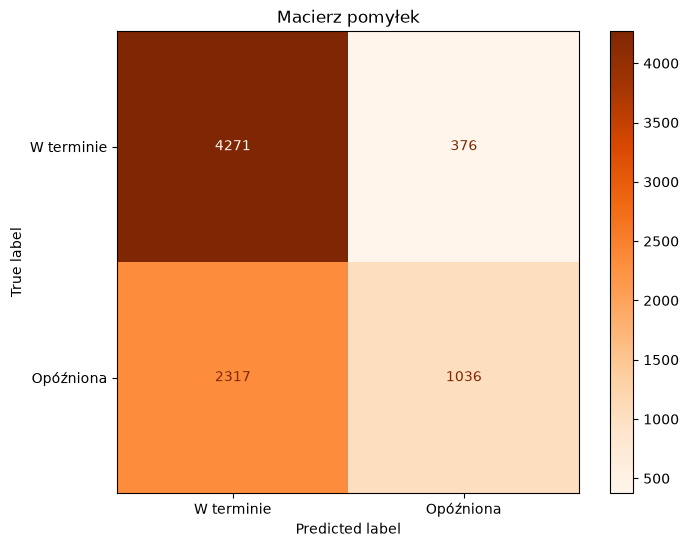

In [13]:
roc_auc = roc_auc_score(y_test, y_pred_prob)
avg_prec = average_precision_score(y_test, y_pred_prob)

conf_matrix = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['W terminie', 'Opóźniona'])

print("Raport klasyfikacji:")
print(classification_report(y_test, y_pred_class, target_names=['W terminie', 'Opóźniona']))

print(f"ROC-AUC: {roc_auc:.4f}\n")
print(f"AP: {avg_prec:.4f}\n")

fig, ax = plt.subplots()
disp.plot(ax=ax, cmap='Oranges', values_format='d')
plt.title('Macierz pomyłek')
plt.show()

### Wnioski
&emsp;Możemy zauważyc, że wskaźnik ROC_AUC oraz precyzja dla opóźnień są na poziomie potwierdzającym wartość analityczną cech wektora wejściowego. Z kolei czułość wykrywania opóźnień wynosi jedynie 0.31. Model bazowy pomylił się aż przy 2317 opóźnionych fakturach klasyfikując je jako terminowe.